In [27]:
!pip install imbalanced-learn openpyxl -q

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
from google.colab import files

uploaded = files.upload()

Saving Motives.csv to Motives (1).csv
Saving Causes.csv to Causes (1).csv
Saving Cases (1).csv to Cases (1) (1).csv


In [30]:
import os

print(os.listdir())

['.config', 'Causes (1).csv', 'Motives.csv', 'Causes.csv', 'CyberCrime_Model_Results.xlsx', 'Cases (1) (1).csv', 'Motives (1).csv', 'Cases (1).csv', 'sample_data']


In [31]:
motives_df = pd.read_csv("Motives.csv")
causes_df = pd.read_csv("Causes.csv")
cases_df = pd.read_csv("Cases (1).csv")

print("Motives:", motives_df.shape)
print("Causes:", causes_df.shape)
print("Cases:", cases_df.shape)

Motives: (37, 20)
Causes: (37, 27)
Cases: (36, 9)


In [32]:
motives_df.columns = motives_df.columns.str.strip()
causes_df.columns = causes_df.columns.str.strip()
cases_df.columns = cases_df.columns.str.strip()

motives_df["State/UT"] = motives_df["State/UT"].str.strip()
causes_df["State/UT"] = causes_df["State/UT"].str.strip()
cases_df["State/UT"] = cases_df["State/UT"].str.strip()

print("Column names cleaned successfully!")

Column names cleaned successfully!


In [33]:
motives_df = motives_df[
    motives_df["State/UT"].str.upper() != "TOTAL ALL INDIA"
]

causes_df = causes_df[
    causes_df["State/UT"].str.upper() != "TOTAL ALL INDIA"
]

cases_df = cases_df[
    cases_df["State/UT"].str.upper() != "TOTAL ALL INDIA"
]

print("Motives:", motives_df.shape)
print("Causes:", causes_df.shape)
print("Cases:", cases_df.shape)

Motives: (36, 20)
Causes: (36, 27)
Cases: (36, 9)


In [34]:
combined_df = (
    cases_df
    .merge(causes_df, on="State/UT", how="inner")
    .merge(motives_df, on="State/UT", how="inner")
)

print("Final dataset shape:", combined_df.shape)

display(combined_df.head())

Final dataset shape: (36, 54)


,State/UT,2018,2019,2020,2021,2022,Mid-Year Projected Population (in Lakhs),Rate of Total Cyber Crimes (2022),Chargesheeting Rate (2022),Computer Related Offences,...,Inciting Hate against Country,Disrupt Public Service,Sale Purchase illegal drugs,Developing own business,Spreading Piracy,Psycho or Pervert,Steal Information,Abetment to Suicide,Others,Total
0,Andhra Pradesh,1207,1886,1899,1875,2341,530.3,4.4,16.8,257,...,0,28,0,9,4,0,3,2,505,2341
1,A&N Islands,7,2,5,8,28,4.0,7.0,63.6,4,...,0,0,0,0,0,0,0,0,12,28
2,Arunachal Pradesh,7,8,30,47,14,15.5,0.9,50.0,7,...,0,0,0,0,0,0,0,0,5,14
3,Assam,2022,2231,3530,4846,1733,354.9,4.9,14.0,592,...,1,3,0,0,0,0,0,0,447,1733
4,Bihar,374,1050,1512,1413,1621,1255.3,1.3,69.3,14,...,0,0,0,0,0,0,0,0,14,1621


In [35]:
print("DATASET INFORMATION")
print("=" * 50)

combined_df.info()

print("\n\nMISSING VALUES")
print("=" * 50)

print(combined_df.isnull().sum())

print("\n\nSTATISTICAL SUMMARY")
print("=" * 50)

display(combined_df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 54 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   State/UT                                                                         36 non-null     object 
 1   2018                                                                             36 non-null     int64  
 2   2019                                                                             36 non-null     int64  
 3   2020                                                                             36 non-null     int64  
 4   2021                                                                             36 non-null     int64  
 5   2022                                                                             36 non-null     int64

,2018,2019,2020,2021,2022,Mid-Year Projected Population (in Lakhs),Rate of Total Cyber Crimes (2022),Computer Related Offences,Publication/ transmission of obscene / sexually explicit act in electronic form,Other Sections of IT Act,...,Inciting Hate against Country,Disrupt Public Service,Sale Purchase illegal drugs,Developing own business,Spreading Piracy,Psycho or Pervert,Steal Information,Abetment to Suicide,Others,Total
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,756.888889,1237.388889,1389.861111,1471.500000,1830.361111,383.261111,4.011111,663.722222,191.555556,28.250000,...,0.944444,1.944444,0.305556,29.666667,2.472222,0.055556,3.805556,0.111111,299.750000,1830.361111
std,1481.867678,2775.022175,2694.016578,2649.114564,3666.629766,497.400312,7.010554,2170.749043,406.538169,69.079819,...,2.745848,5.042360,1.508442,157.658039,7.473711,0.333333,22.324643,0.398410,621.034086,3666.629766
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.700000,0.100000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,18.500000,8.000000,26.750000,28.500000,27.750000,16.075000,1.000000,10.500000,5.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000,27.750000
50%,180.000000,145.000000,270.000000,434.500000,499.000000,255.250000,2.300000,55.500000,33.500000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.500000,499.000000
75%,765.750000,1061.250000,1300.750000,1435.750000,1649.000000,566.250000,4.300000,257.000000,201.750000,18.500000,...,0.000000,1.250000,0.000000,2.250000,2.000000,0.000000,0.000000,0.000000,291.500000,1649.000000
max,6280.000000,12020.000000,11097.000000,10303.000000,15297.000000,2340.900000,40.300000,11729.000000,2309.000000,295.000000,...,13.000000,28.000000,9.000000,947.000000,43.000000,2.000000,134.000000,2.000000,2585.000000,15297.000000


In [36]:
for column in combined_df.columns:

    if column != "State/UT":

        combined_df[column] = pd.to_numeric(
            combined_df[column],
            errors="coerce"
        )

print("Numerical conversion completed.")

Numerical conversion completed.


In [37]:
numeric_columns = combined_df.select_dtypes(
    include=np.number
).columns

combined_df[numeric_columns] = combined_df[
    numeric_columns
].fillna(
    combined_df[numeric_columns].median()
)

print("Missing values after treatment:")

print(
    combined_df.isnull().sum().sum()
)

Missing values after treatment:
0


In [38]:
median_cases = combined_df["2022"].median()

print("Median 2022 cybercrime cases:", median_cases)

combined_df["Crime_Level"] = np.where(
    combined_df["2022"] > median_cases,
    1,
    0
)

combined_df["Crime_Level_Label"] = combined_df[
    "Crime_Level"
].map({
    0: "Low Risk",
    1: "High Risk"
})

display(
    combined_df[
        [
            "State/UT",
            "2022",
            "Crime_Level",
            "Crime_Level_Label"
        ]
    ]
)

Median 2022 cybercrime cases: 499.0


,State/UT,2022,Crime_Level,Crime_Level_Label
0,Andhra Pradesh,2341,1,High Risk
1,A&N Islands,28,0,Low Risk
2,Arunachal Pradesh,14,0,Low Risk
3,Assam,1733,1,High Risk
4,Bihar,1621,1,High Risk
5,Chhattisgarh,439,0,Low Risk
6,Goa,90,0,Low Risk
7,Chandigarh,27,0,Low Risk
8,Gujarat,1417,1,High Risk
9,Haryana,681,1,High Risk


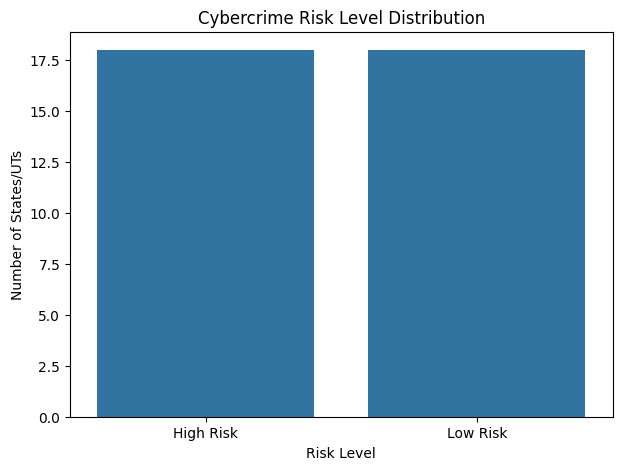

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=combined_df,
    x="Crime_Level_Label"
)

plt.title("Cybercrime Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of States/UTs")

plt.show()

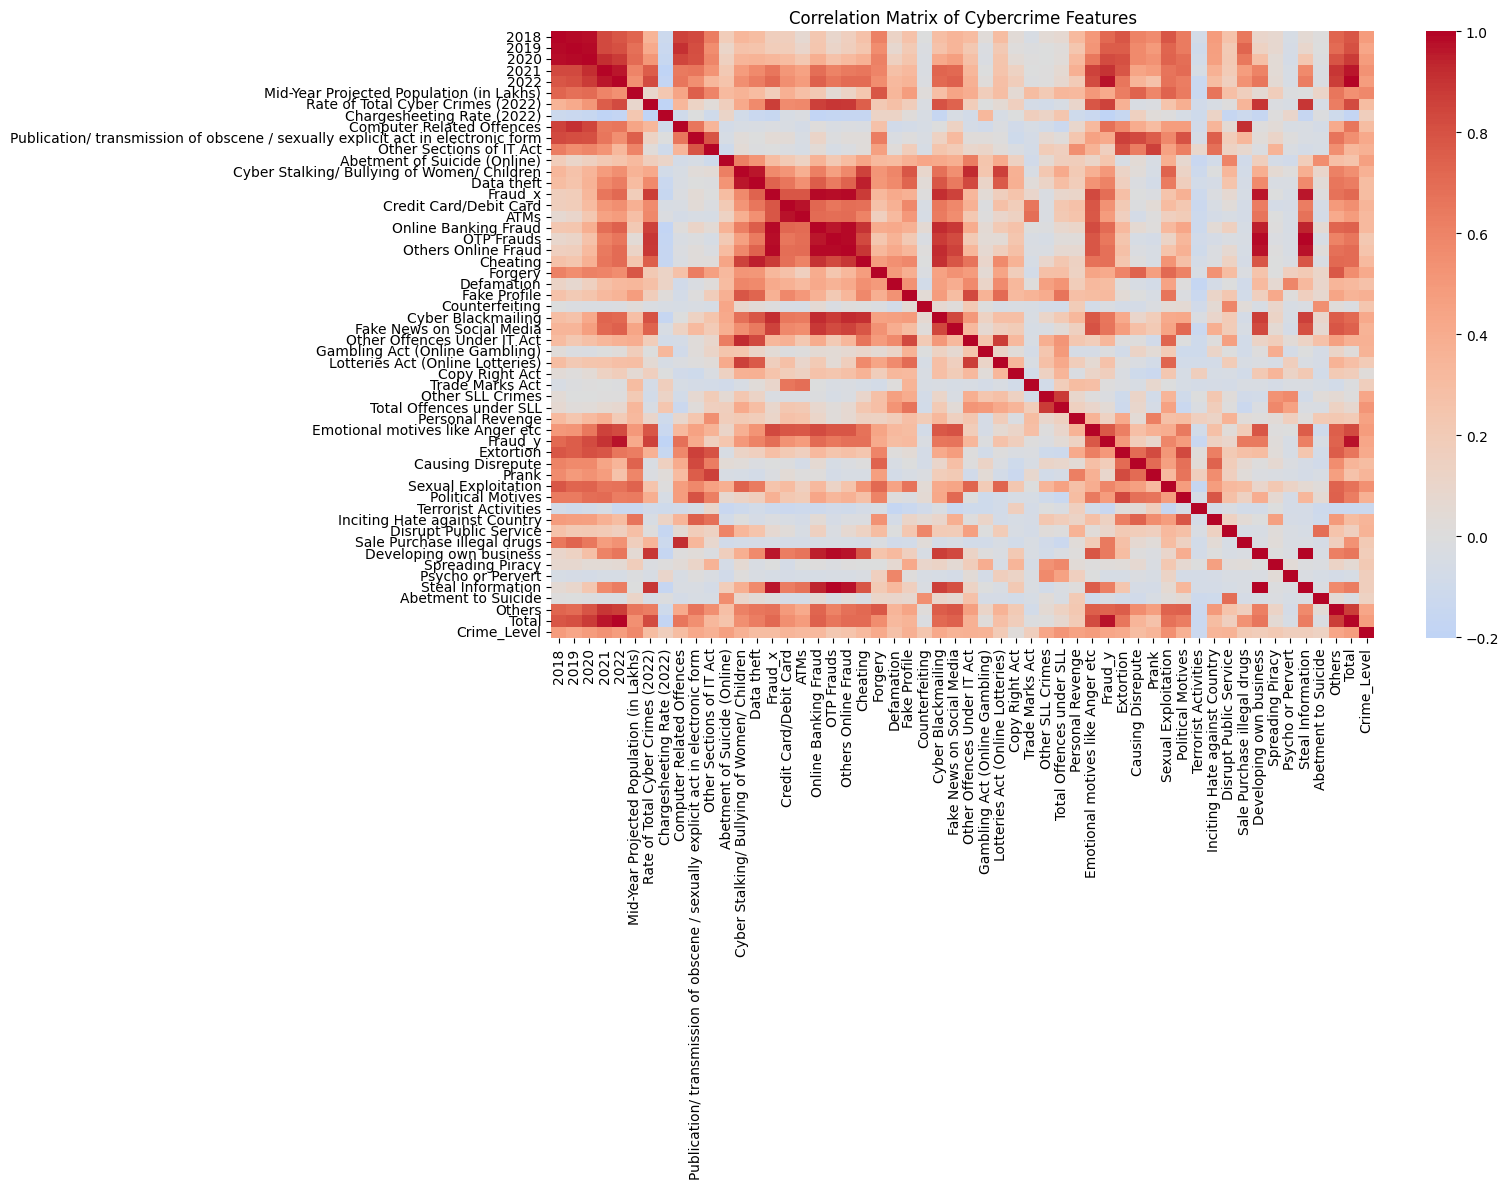

In [40]:
numeric_df = combined_df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(16,12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Cybercrime Features")

plt.tight_layout()

plt.show()

In [41]:
leakage_columns = [
    "State/UT",
    "2022",
    "Crime_Level",
    "Crime_Level_Label",
    "Total",
    "Rate of Total Cyber Crimes (2022)",
    "Chargesheeting Rate (2022)"
]

X = combined_df.drop(
    columns=leakage_columns,
    errors="ignore"
)

y = combined_df["Crime_Level"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nFeatures being used:")
print(X.columns.tolist())

Features: (36, 49)
Target: (36,)

Features being used:
['2018', '2019', '2020', '2021', 'Mid-Year Projected Population (in Lakhs)', 'Computer Related Offences', 'Publication/ transmission of obscene / sexually explicit act in electronic form', 'Other Sections of IT Act', 'Abetment of Suicide (Online)', 'Cyber Stalking/ Bullying of Women/ Children', 'Data theft', 'Fraud_x', 'Credit Card/Debit Card', 'ATMs', 'Online Banking Fraud', 'OTP Frauds', 'Others Online Fraud', 'Cheating', 'Forgery', 'Defamation', 'Fake Profile', 'Counterfeiting', 'Cyber Blackmailing', 'Fake News on Social Media', 'Other Offences Under IT Act', 'Gambling Act (Online Gambling)', 'Lotteries Act (Online Lotteries)', 'Copy Right Act', 'Trade Marks Act', 'Other SLL Crimes', 'Total Offences under SLL', 'Personal Revenge', 'Emotional motives like Anger etc', 'Fraud_y', 'Extortion', 'Causing Disrepute', 'Prank', 'Sexual Exploitation', 'Political Motives', 'Terrorist Activities', 'Inciting Hate against Country', 'Disrupt P

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training data: (28, 49)
Testing data: (8, 49)

Training target distribution:
Crime_Level
0    14
1    14
Name: count, dtype: int64


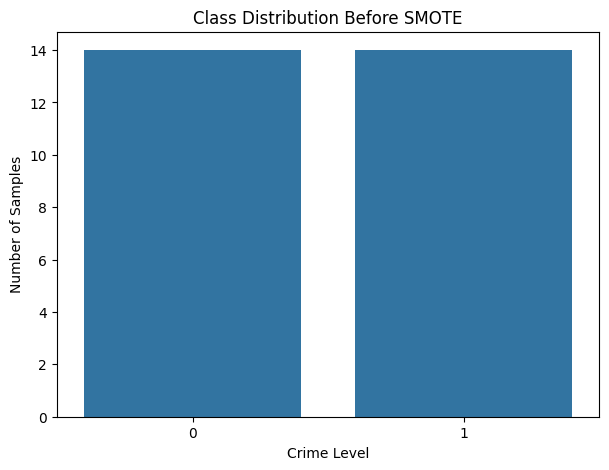

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(x=y_train)

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Crime Level")
plt.ylabel("Number of Samples")

plt.show()

In [44]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

print("Models created:", len(models))

Models created: 6


In [45]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[

            (
                "imputer",
                SimpleImputer(strategy="median")
            ),

            (
                "scaler",
                StandardScaler()
            ),

            (
                "feature_selection",
                SelectKBest(
                    score_func=f_classif,
                    k=min(10, X.shape[1])
                )
            ),

            (
                "smote",
                SMOTE(
                    random_state=42,
                    k_neighbors=3
                )
            ),

            (
                "model",
                model
            )
        ]
    )

print("All ML pipelines created successfully!")

All ML pipelines created successfully!


In [46]:
results = []

trained_models = {}

for name, pipeline in pipelines.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[name] = pipeline

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Low Risk",
                "High Risk"
            ],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

    Low Risk       0.75      0.75      0.75         4
   High Risk       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8


SVM
              precision    recall  f1-score   support

    Low Risk       0.75      0.75      0.75         4
   High Risk       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8


KNN
              precision    recall  f1-score   support

    Low Risk       0.60      0.75      0.67         4
   High Risk       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62

In [47]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Random Forest,0.875,1.000000,0.75,0.857143,1.00000
3,Decision Tree,0.875,1.000000,0.75,0.857143,0.87500
5,Gradient Boosting,0.875,1.000000,0.75,0.857143,0.87500
0,Logistic Regression,0.750,0.750000,0.75,0.750000,0.87500
1,SVM,0.750,0.750000,0.75,0.750000,0.75000
2,KNN,0.625,0.666667,0.50,0.571429,0.78125


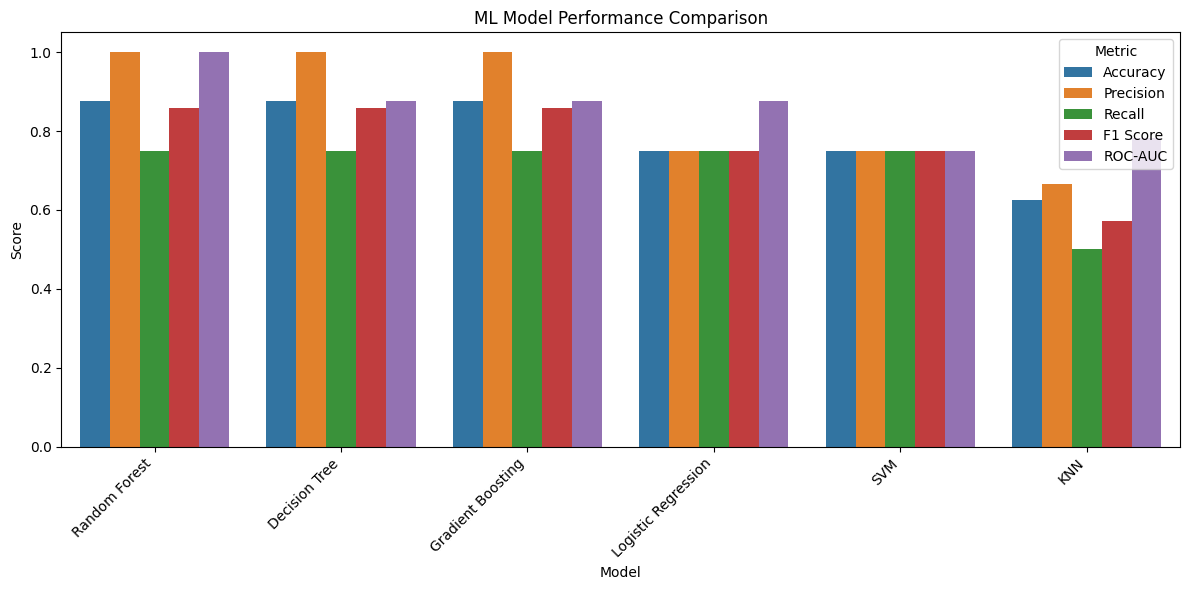

In [48]:
plt.figure(figsize=(12,6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1.05)

plt.title("ML Model Performance Comparison")

plt.tight_layout()

plt.show()

In [49]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Random Forest


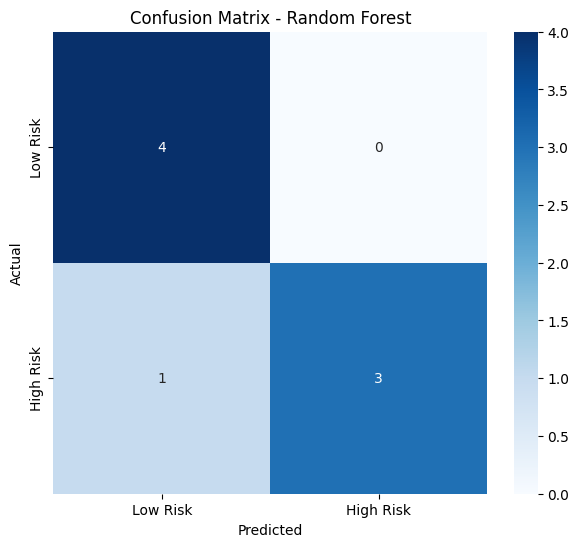

In [50]:
best_predictions = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk",
        "High Risk"
    ],
    yticklabels=[
        "Low Risk",
        "High Risk"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

In [51]:
results_df.to_excel(
    "CyberCrime_Model_Results.xlsx",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [52]:
from google.colab import files

files.download(
    "CyberCrime_Model_Results.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>